# Financial Market Analysis in Python

This project compares several financial assets using Python.  
The goal is to analyse return, risk, volatility, drawdown, and risk-adjusted performance.

Assets analysed:

- Apple
- Nvidia
- Tesla
- Bitcoin
- S&P 500
- Gold

In [15]:
!pip install yfinance

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [17]:
tickers = ["AAPL", "NVDA", "TSLA", "BTC-USD", "^GSPC", "GC=F"]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=True
)["Close"]

data.head()


[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,BTC-USD,GC=F,NVDA,TSLA,^GSPC
Date,,,,,,
2020-01-01,NaN,7200.174316,NaN,NaN,NaN,NaN
2020-01-02,72.333885,6985.470215,1524.500000,5.963803,28.684,3257.850098
2020-01-03,71.630638,7344.884277,1549.199951,5.868348,29.534,3234.850098
2020-01-04,NaN,7410.656738,NaN,NaN,NaN,NaN
2020-01-05,NaN,7411.317383,NaN,NaN,NaN,NaN


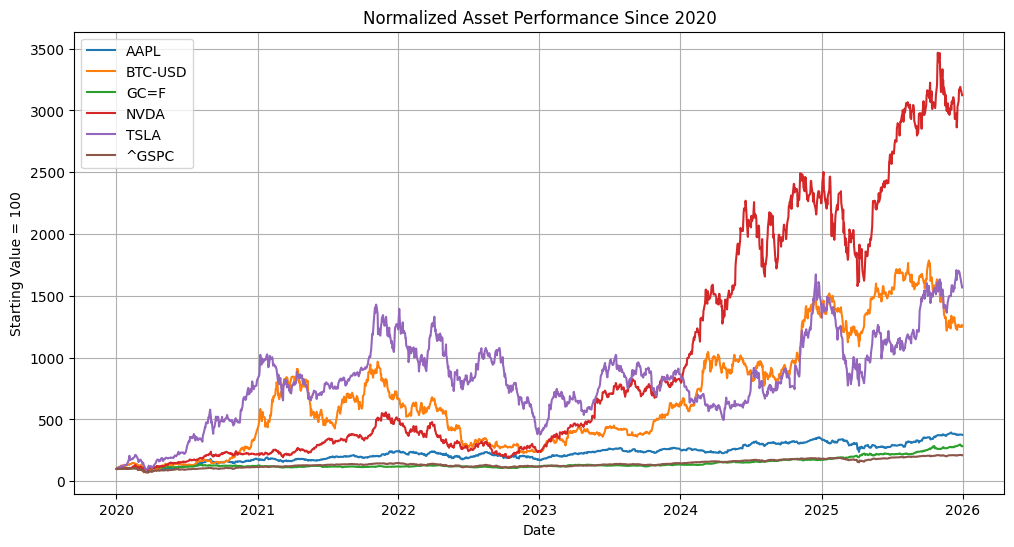

In [18]:
data = data.dropna()

normalized_data = data / data.iloc[0] * 100

plt.figure(figsize=(12, 6))

for ticker in normalized_data.columns:
    plt.plot(normalized_data.index, normalized_data[ticker], label=ticker)

plt.title("Normalized Asset Performance Since 2020")
plt.xlabel("Date")
plt.ylabel("Starting Value = 100")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
daily_returns = data.pct_change().dropna()

daily_returns.head()

Ticker,AAPL,BTC-USD,GC=F,NVDA,TSLA,^GSPC
Date,,,,,,
2020-01-03,-0.009722,0.051452,0.016202,-0.016006,0.029633,-0.007060
2020-01-06,0.007968,0.057773,0.010973,0.004194,0.019255,0.003533
2020-01-07,-0.004703,0.050774,0.003576,0.012106,0.038801,-0.002803
2020-01-08,0.016086,-0.010269,-0.009161,0.001876,0.049205,0.004902
2020-01-09,0.021240,-0.024851,-0.003660,0.010983,-0.021945,0.006655


In [20]:
total_returns = (data.iloc[-1] / data.iloc[0] - 1) * 100

total_returns.sort_values(ascending=False)

,0
Ticker,
NVDA,3023.389852
TSLA,1467.842703
BTC-USD,1152.726380
AAPL,275.143453
GC=F,183.738937
^GSPC,110.123234


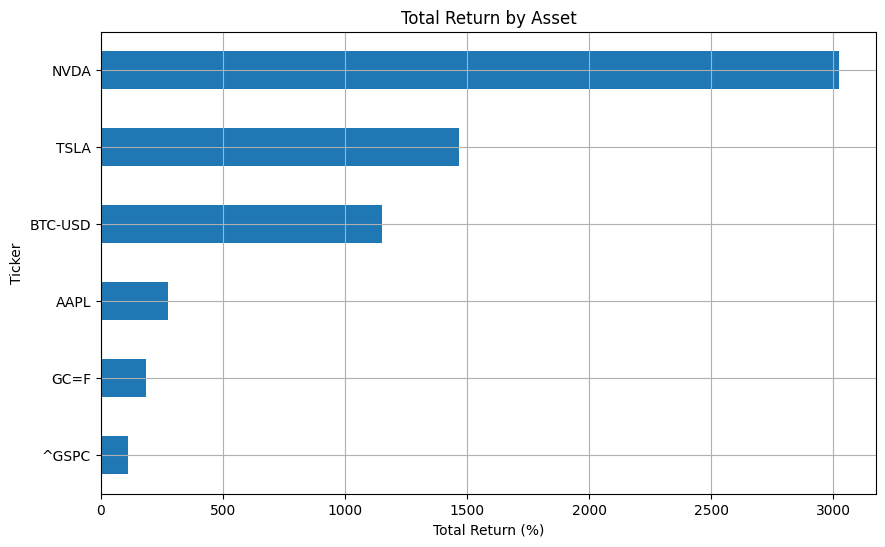

In [21]:
plt.figure(figsize=(10, 6))

total_returns.sort_values().plot(kind="barh")

plt.title("Total Return by Asset")
plt.xlabel("Total Return (%)")
plt.grid(True)
plt.show()

In [22]:
annual_volatility = daily_returns.std() * np.sqrt(252) * 100

annual_volatility.sort_values(ascending=False)

,0
Ticker,
TSLA,66.570910
BTC-USD,61.392742
NVDA,53.184873
AAPL,31.809491
^GSPC,20.927113
GC=F,17.076323


In [23]:
annual_return = daily_returns.mean() * 252 * 100

annual_return.sort_values(ascending=False)

,0
Ticker,
NVDA,71.650779
TSLA,68.111946
BTC-USD,61.486644
AAPL,27.158883
GC=F,18.904882
^GSPC,14.615983


In [24]:
sharpe_ratio = annual_return / annual_volatility

sharpe_ratio.sort_values(ascending=False)

,0
Ticker,
NVDA,1.347202
GC=F,1.107081
TSLA,1.023149
BTC-USD,1.001530
AAPL,0.853798
^GSPC,0.698423


In [25]:
cumulative_returns = (1 + daily_returns).cumprod()

running_max = cumulative_returns.cummax()

drawdown = (cumulative_returns / running_max - 1) * 100

max_drawdown = drawdown.min()

max_drawdown.sort_values()

,0
Ticker,
BTC-USD,-76.634564
TSLA,-73.632217
NVDA,-66.335096
^GSPC,-33.924960
AAPL,-33.360514
GC=F,-20.872530


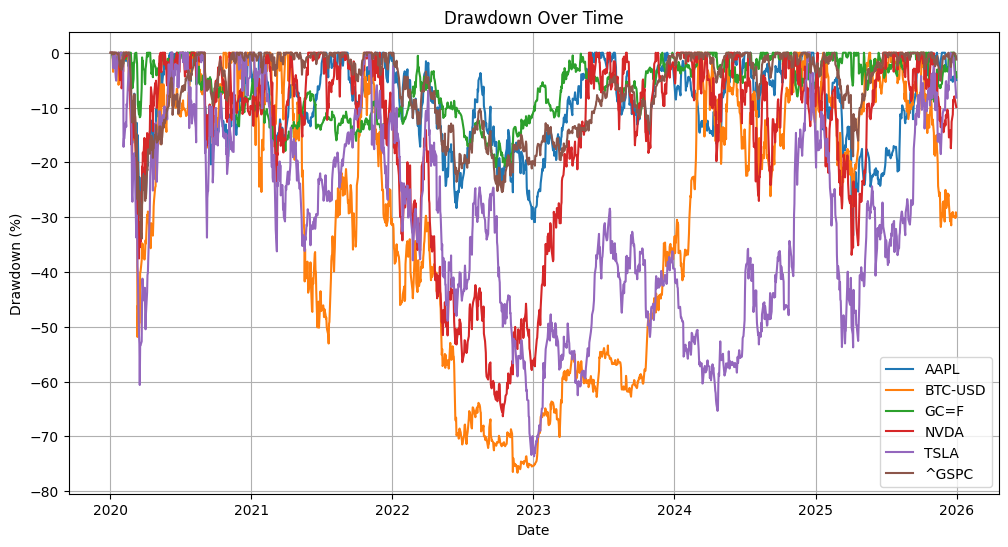

In [27]:
plt.figure(figsize=(12, 6))

for ticker in drawdown.columns:
    plt.plot(drawdown.index, drawdown[ticker], label=ticker)

plt.title("Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
summary = pd.DataFrame({
    "Total Return (%)": total_returns,
    "Annual Return (%)": annual_return,
    "Annual Volatility (%)": annual_volatility,
    "Sharpe Ratio": sharpe_ratio,
    "Maximum Drawdown (%)": max_drawdown
})

summary = summary.sort_values("Sharpe Ratio", ascending=False)

summary

,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Maximum Drawdown (%)
Ticker,,,,,
NVDA,3023.389852,71.650779,53.184873,1.347202,-66.335096
GC=F,183.738937,18.904882,17.076323,1.107081,-20.872530
TSLA,1467.842703,68.111946,66.570910,1.023149,-73.632217
BTC-USD,1152.726380,61.486644,61.392742,1.001530,-76.634564
AAPL,275.143453,27.158883,31.809491,0.853798,-33.360514
^GSPC,110.123234,14.615983,20.927113,0.698423,-33.924960


## Conclusion

This project compared Apple, Nvidia, Tesla, Bitcoin, the S&P 500, and gold using historical price data.

The analysis focused on:

- Total return
- Annual return
- Annual volatility
- Sharpe ratio
- Maximum drawdown

The asset with the highest total return was: Nvidia (NVDA), with a total return of about 3023%.

The asset with the highest volatility was: Tesla (TSLA), with annual volatility of about 66.6%.

The asset with the best Sharpe ratio was: Nvidia (NVDA), with a Sharpe ratio of about 1.35.

The asset with the worst maximum drawdown was: Bitcoin (BTC-USD), with a maximum drawdown of about -76.6%.

Overall, this project helped me practise Python, pandas, NumPy, matplotlib, financial data analysis, and basic risk-return analysis.